In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import time
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

matplotlib.use('TkAgg')

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.metrics import confusion_matrix
import seaborn as sns
import os

In [6]:
# Veri setini içe aktar
def load_data(file_path):
    df = pd.read_csv(file_path)
    df = df.dropna()  # Eksik verileri kaldır
    return df

file_path = r'languages.csv'
df = load_data(file_path)
print("Veri seti başarıyla yüklendi.")
df.head()

Veri seti başarıyla yüklendi.


,text,language
0,ich denke es handelt sich hier um ein missvers...,german
1,ich habe tom gerade erst verlassen,german
2,tom versuchte mary nur zu ärgern,german
3,tom hat mir die hand geküsst,german
4,ich wusste dass dir das gefiele,german


In [7]:
# Dil etiketlerini encode et
def encode_labels(df):
    label_encoder = LabelEncoder()
    if 'language' in df.columns:
        df['language_encoded'] = label_encoder.fit_transform(df['language'])
    else:
        raise KeyError("DataFrame'de 'language' sütunu bulunamadı!")
    return df, label_encoder

df, label_encoder = encode_labels(df)
print("Etiketler başarıyla encode edildi.")

Etiketler başarıyla encode edildi.


In [8]:
# Veri setinden rastgele 5 satır çekme
random_rows = df.sample(5)  # Rastgele 5 satır
print("Rastgele 5 satır:")
print(random_rows)

Rastgele 5 satır:
                                               text language  language_encoded
380725  la reunión se llevó a cabo la semana pasada  spanish                 3
56737     es ist mir egal ob ich gewinne oder nicht   german                 2
415493                    tengo menos libros que tú  spanish                 3
646423   i think tom isnt the right man for the job  english                 0
734409                    were you a friend of toms  english                 0


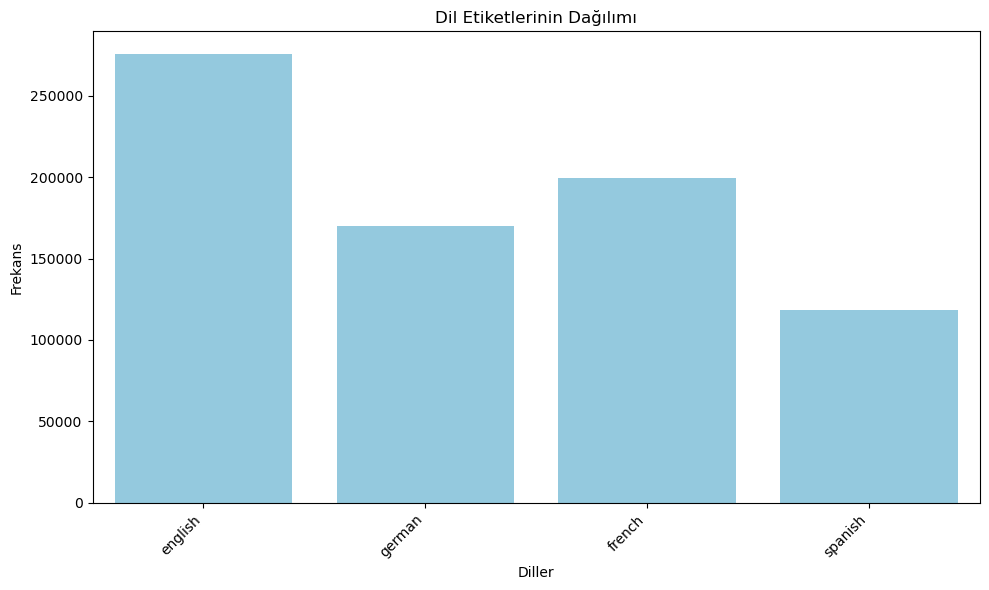

In [58]:
# Dil etiketlerinin dağılımını görselleştir (hue olmadan palette kullanımı düzeltilmiş)
def plot_label_distribution(df, label_column, label_encoder):
    plt.figure(figsize=(10, 6))
    label_counts = df[label_column].value_counts()

    # Renk paleti olmadan manuel renk seçimi
    sns.barplot(
        x=label_counts.index,
        y=label_counts.values,
        color="skyblue"  # Tek renk belirtiyoruz
    )

    # X ekseninde label isimlerini göster
    plt.xticks(
        ticks=range(len(label_counts.index)),
        labels=[label_encoder.inverse_transform([i])[0] for i in label_counts.index],
        rotation=45,
        ha="right"
    )
    plt.xlabel("Diller")
    plt.ylabel("Frekans")
    plt.title("Dil Etiketlerinin Dağılımı")
    plt.tight_layout()
    plt.show()

# Grafiği oluştur ve göster
plot_label_distribution(df, "language_encoded", label_encoder)


In [9]:
# Eğitim ve test verilerini ayır
def split_data(df):
    X = df['text'].values
    y = df['language_encoded'].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=17)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(df)
print(f"Eğitim veri boyutu: {len(X_train)}")
print(f"Test veri boyutu: {len(X_test)}")


Eğitim veri boyutu: 610947
Test veri boyutu: 152737


In [10]:

# TextVectorization işlemi
def create_vectorize_layer(X_train, max_features=60000, sequence_length=20):
    vectorize_layer = TextVectorization(max_tokens=max_features,
                                        output_mode='int',
                                        output_sequence_length=sequence_length)
    vectorize_layer.adapt(X_train)
    return vectorize_layer

vectorize_layer = create_vectorize_layer(X_train)
X_train_vectorized = vectorize_layer(X_train).numpy()
X_test_vectorized = vectorize_layer(X_test).numpy()
print("Text verileri başarıyla vektörleştirildi.")

Text verileri başarıyla vektörleştirildi.


In [12]:
# BiLSTM modeli
def create_bilstm_model(max_features, sequence_length, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(input_dim=max_features + 1, output_dim=128),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, dropout=0.5,return_sequences=False)),
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [13]:

# GRU modeli
def create_gru_model(max_features, sequence_length, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(input_dim=max_features + 1, output_dim=128),
        tf.keras.layers.GRU(128, dropout=0.2, recurrent_dropout=0.2),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model



In [14]:
# LSTM modeli
def create_lstm_model(max_features, sequence_length, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(input_dim=max_features + 1, output_dim=128),
        tf.keras.layers.LSTM(128, dropout=0.5, recurrent_dropout=0.5),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [15]:
# EarlyStopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)


In [18]:

# Sınıf sayısını belirle
num_classes = len(label_encoder.classes_)

# BiLSTM modelini oluştur
model_bilstm = create_bilstm_model(max_features=60000, sequence_length=20, num_classes=num_classes)

# GRU modelini oluştur
model_gru = create_gru_model(max_features=60000, sequence_length=20, num_classes=num_classes)

# LSTM modelini oluştur
model_lstm = create_lstm_model(max_features=60000, sequence_length=20, num_classes=num_classes)


# Modeli eğit
def train_model(model, X_train_vectorized, y_train, X_test_vectorized, y_test, epochs=5, batch_size=64):
    start_time = time.time()
    history = model.fit(X_train_vectorized, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test_vectorized, y_test))
    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training Time: {training_time/60:.2f} minutes")
    return history

print("BiLSTM Modeli Eğitiliyor...")
history_bilstm = train_model(model_bilstm, X_train_vectorized, y_train, X_test_vectorized, y_test)

print("GRU Modeli Eğitiliyor...")
history_gru = train_model(model_gru, X_train_vectorized, y_train, X_test_vectorized, y_test)

print("LSTM Modeli Eğitiliyor...")
history_lstm = train_model(model_lstm, X_train_vectorized, y_train, X_test_vectorized, y_test)


BiLSTM Modeli Eğitiliyor...
Epoch 1/5
9547/9547 ━━━━━━━━━━━━━━━━━━━━ 651s 67ms/step - accuracy: 0.9766 - loss: 0.1264 - val_accuracy: 0.9979 - val_loss: 0.0121
Epoch 2/5
9547/9547 ━━━━━━━━━━━━━━━━━━━━ 653s 68ms/step - accuracy: 0.9983 - loss: 0.0128 - val_accuracy: 0.9983 - val_loss: 0.0111
Epoch 3/5
9547/9547 ━━━━━━━━━━━━━━━━━━━━ 655s 69ms/step - accuracy: 0.9986 - loss: 0.0116 - val_accuracy: 0.9984 - val_loss: 0.0104
Epoch 4/5
9547/9547 ━━━━━━━━━━━━━━━━━━━━ 662s 69ms/step - accuracy: 0.9987 - loss: 0.0108 - val_accuracy: 0.9985 - val_loss: 0.0112
Epoch 5/5
9547/9547 ━━━━━━━━━━━━━━━━━━━━ 660s 69ms/step - accuracy: 0.9987 - loss: 0.0111 - val_accuracy: 0.9985 - val_loss: 0.0105
Training Time: 54.68 minutes
GRU Modeli Eğitiliyor...
Epoch 1/5
9547/9547 ━━━━━━━━━━━━━━━━━━━━ 614s 64ms/step - accuracy: 0.9543 - loss: 0.1020 - val_accuracy: 0.7325 - val_loss: 1.0164
Epoch 2/5
9547/9547 ━━━━━━━━━━━━━━━━━━━━ 611s 64ms/step - accuracy: 0.9990 - loss: 0.0029 - val_accuracy: 0.9304 - val_loss: 0

In [54]:
# Eğitim ve doğrulama metriklerini görselleştir
def plot_training_history(history, title):
    plt.figure(figsize=(12, 6))

    # Loss Grafiği
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    # Accuracy Grafiği
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()



BiLSTM Training Metrics:


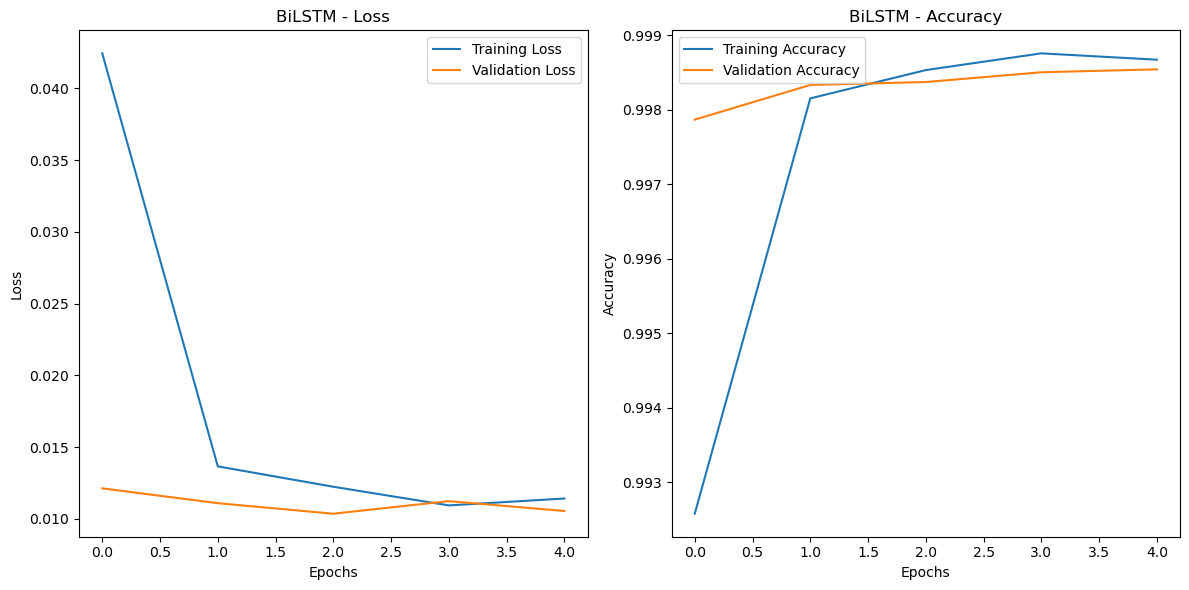

In [26]:
# BiLSTM Modelinin Eğitim Grafikleri
print("\nBiLSTM Training Metrics:")
plot_training_history(history_bilstm, "BiLSTM")


GRU Training Metrics:


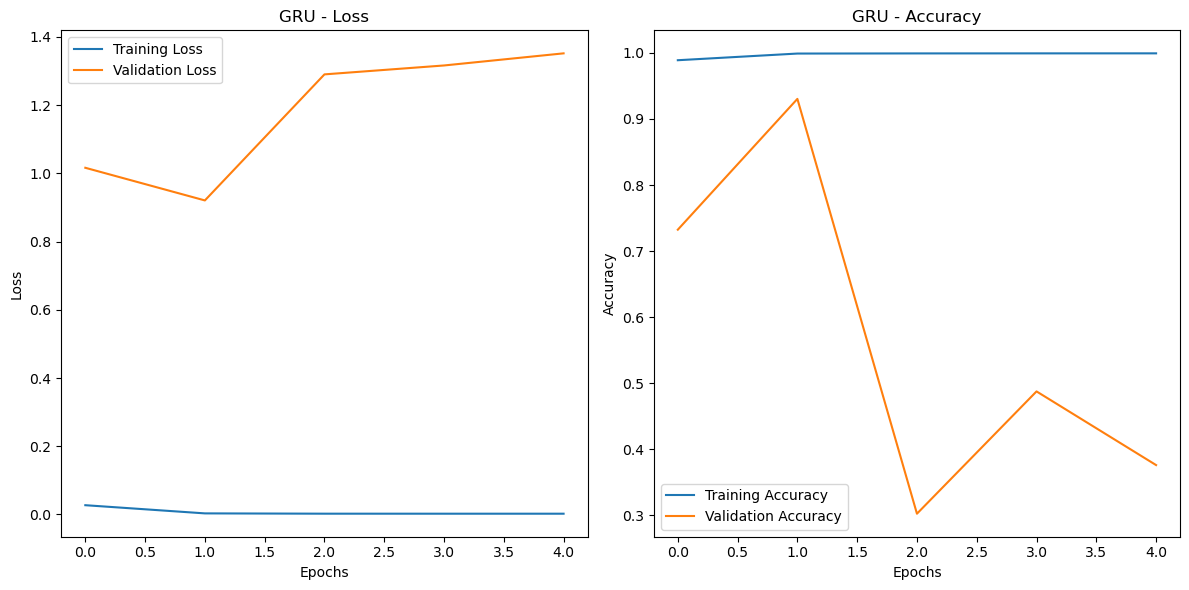

In [27]:
# GRU Modelinin Eğitim Grafikleri
print("\nGRU Training Metrics:")
plot_training_history(history_gru, "GRU")


LSTM Training Metrics:


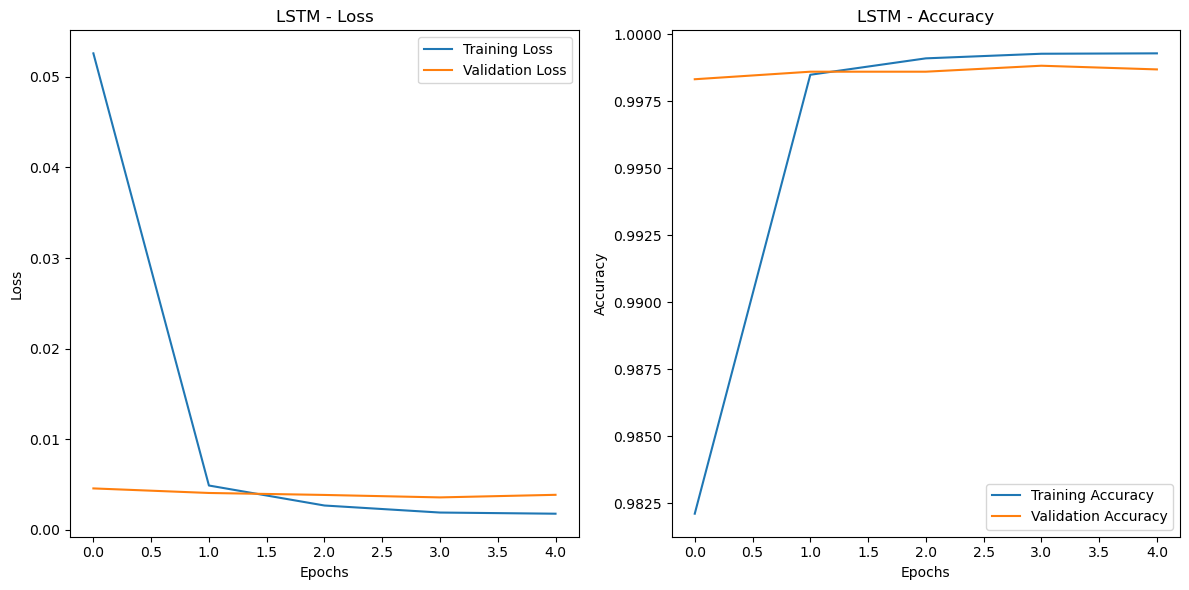

In [28]:
# LSTM Modelinin Eğitim Grafikleri
print("\nLSTM Training Metrics:")
plot_training_history(history_lstm, "LSTM")

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_metrics(model, X_test_vectorized, y_test, average='weighted'):
    y_pred = model.predict(X_test_vectorized)
    y_pred_classes = y_pred.argmax(axis=1)  # Yalnızca sınıf etiketlerini alıyoruz
    
    accuracy = accuracy_score(y_test, y_pred_classes)  # Accuracy hesaplanıyor
    precision = precision_score(y_test, y_pred_classes, average=average, zero_division=0)
    recall = recall_score(y_test, y_pred_classes, average=average, zero_division=0)
    f1 = f1_score(y_test, y_pred_classes, average=average, zero_division=0)
    
    return accuracy, precision, recall, f1


In [30]:
# BiLSTM Modeli Metrikleri
bilstm_accuracy, bilstm_precision, bilstm_recall, bilstm_f1 = evaluate_metrics(model_bilstm, X_test_vectorized, y_test)
# GRU Modeli Metrikleri
gru_accuracy, gru_precision, gru_recall, gru_f1 = evaluate_metrics(model_gru, X_test_vectorized, y_test)
# LSTM Modeli Metrikleri
lstm_accuracy, lstm_precision, lstm_recall, lstm_f1 = evaluate_metrics(model_lstm, X_test_vectorized, y_test)

4774/4774 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step
4774/4774 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step
4774/4774 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step


In [31]:
# Sonuçları tabloya dökme
metrics_df = pd.DataFrame({
    'Model': ['BiLSTM', 'GRU', 'LSTM'],
    'Accuracy': [bilstm_accuracy, gru_accuracy, lstm_accuracy],
    'Precision': [bilstm_precision, gru_precision, lstm_precision],
    'Recall': [bilstm_recall, gru_recall, lstm_recall],
    'F1 Score': [bilstm_f1, gru_f1, lstm_f1]
})

print(metrics_df)

    Model  Accuracy  Precision    Recall  F1 Score
0  BiLSTM  0.998540   0.998542  0.998540  0.998540
1     GRU  0.376287   0.767809  0.376287  0.211460
2    LSTM  0.998691   0.998694  0.998691  0.998691


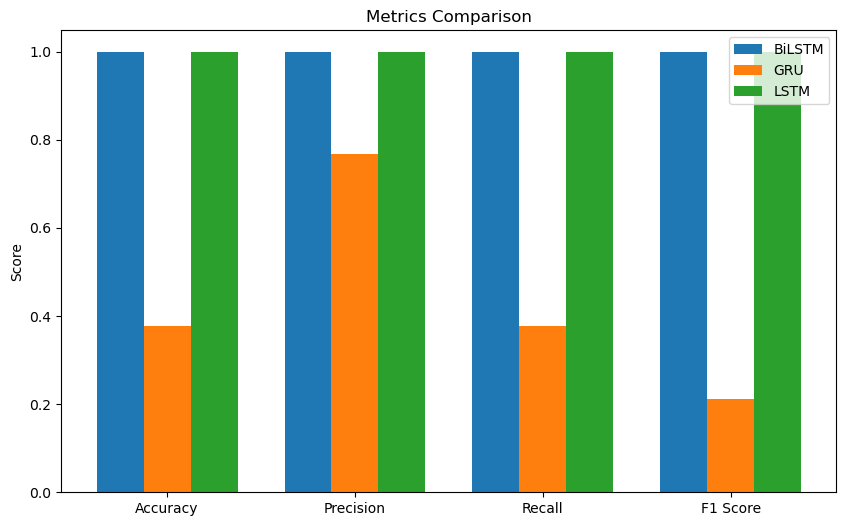

In [60]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
bilstm_metrics = [bilstm_accuracy, bilstm_precision, bilstm_recall, bilstm_f1]
gru_metrics = [gru_accuracy, gru_precision, gru_recall, gru_f1]
lstm_metrics = [lstm_accuracy, lstm_precision, lstm_recall, lstm_f1]

x = range(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar([p - width for p in x], bilstm_metrics, width=width, label='BiLSTM')
plt.bar(x, gru_metrics, width=width, label='GRU')
plt.bar([p + width for p in x], lstm_metrics, width=width, label='LSTM')

plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Metrics Comparison')
plt.legend()
plt.show()


In [32]:
# ROC Eğrisi Çizme Fonksiyonu
def plot_roc_curve(model, X_test_vectorized, y_test, num_classes, title):
    y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))
    y_pred_prob = model.predict(X_test_vectorized)

    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Class {i} (area = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {title}')
    plt.legend(loc="lower right")
    plt.show()

BiLSTM Model ROC Curve:
4774/4774 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step


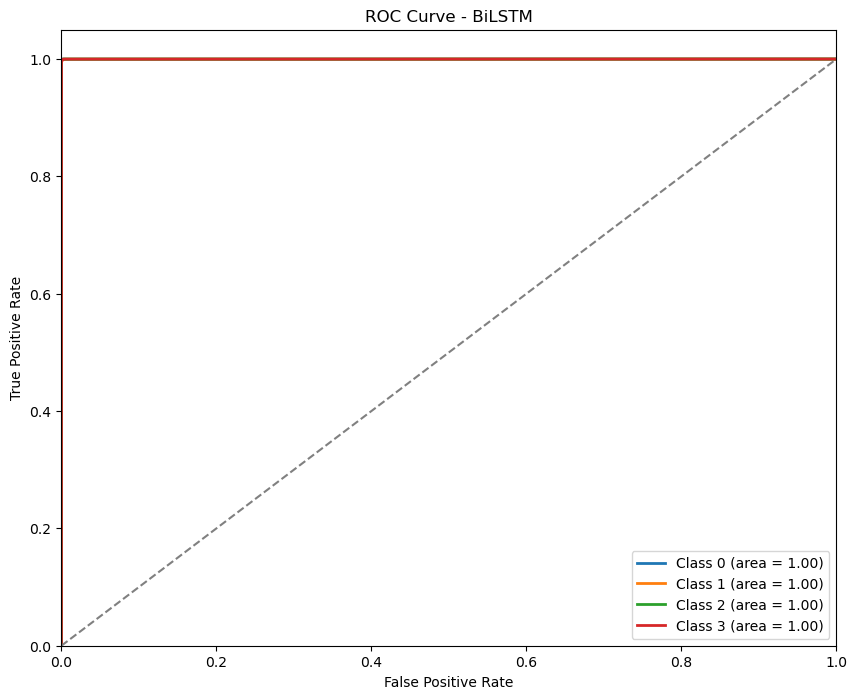

In [33]:
# BiLSTM Modeli için ROC Eğrisi
print("BiLSTM Model ROC Curve:")
plot_roc_curve(model_bilstm, X_test_vectorized, y_test, len(label_encoder.classes_), "BiLSTM")

GRU Model ROC Curve:
4774/4774 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step


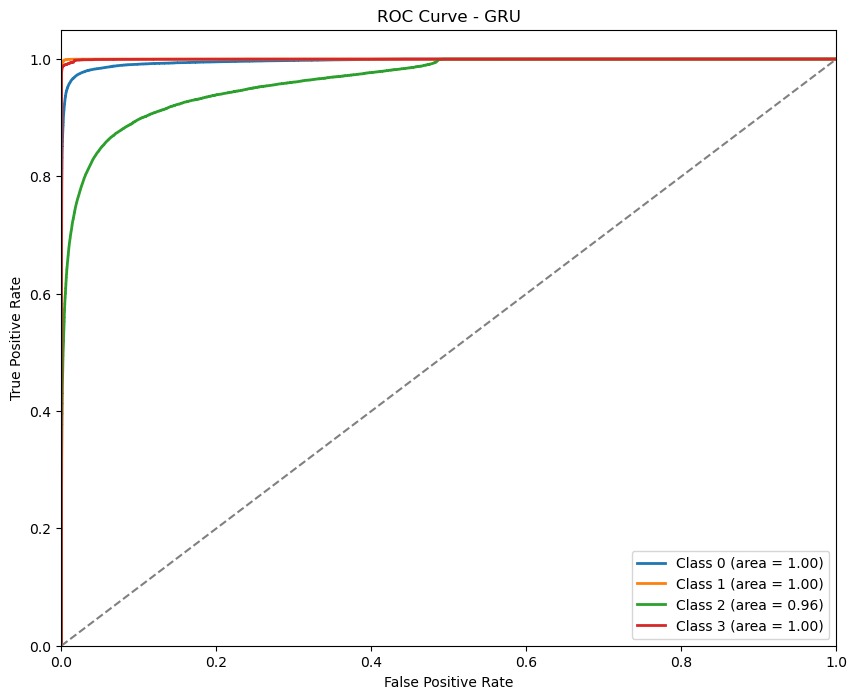

In [34]:
# GRU Modeli için ROC Eğrisi
print("GRU Model ROC Curve:")
plot_roc_curve(model_gru, X_test_vectorized, y_test, len(label_encoder.classes_), "GRU")

LSTM Model ROC Curve:
4774/4774 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step


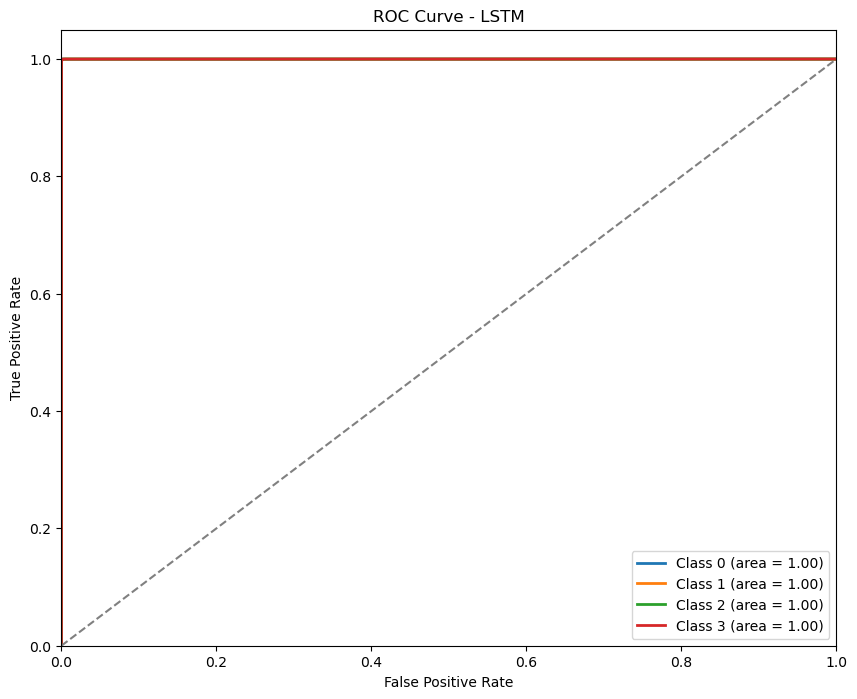

In [35]:
# LSTM Modeli için ROC Eğrisi
print("LSTM Model ROC Curve:")
plot_roc_curve(model_lstm, X_test_vectorized, y_test, len(label_encoder.classes_), "LSTM")

In [36]:
# Konfüzyon Matrisi Çizme Fonksiyonu
def plot_confusion_matrix(model, X_test_vectorized, y_test, label_encoder, title):
    # Model ile tahmin yap
    y_pred = model.predict(X_test_vectorized)
    y_pred_classes = y_pred.argmax(axis=1)

    # Konfüzyon matrisini oluştur
    cm = confusion_matrix(y_test, y_pred_classes)

    # Etiketleri al
    labels = label_encoder.classes_

    # Matrisin görselleştirilmesi
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    plt.figure(figsize=(10, 8))
    disp.plot(cmap=plt.cm.Blues, values_format="d")
    plt.title(f'Confusion Matrix - {title}')
    plt.show()

BiLSTM Modeli Konfüzyon Matrisi:
4774/4774 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step


<Figure size 1000x800 with 0 Axes>

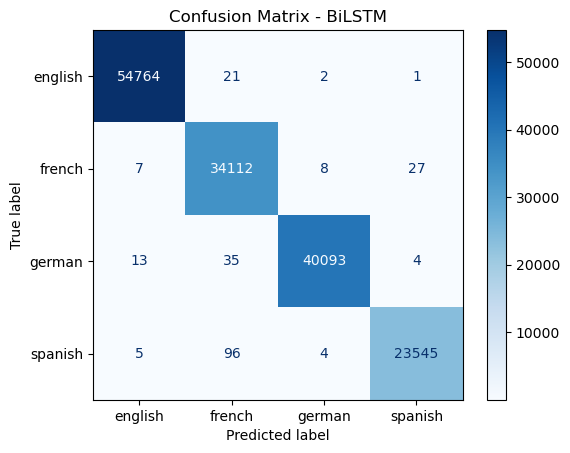

In [37]:
print("BiLSTM Modeli Konfüzyon Matrisi:")
plot_confusion_matrix(model_bilstm, X_test_vectorized, y_test, label_encoder, "BiLSTM")


GRU Modeli Konfüzyon Matrisi:
4774/4774 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step


<Figure size 1000x800 with 0 Axes>

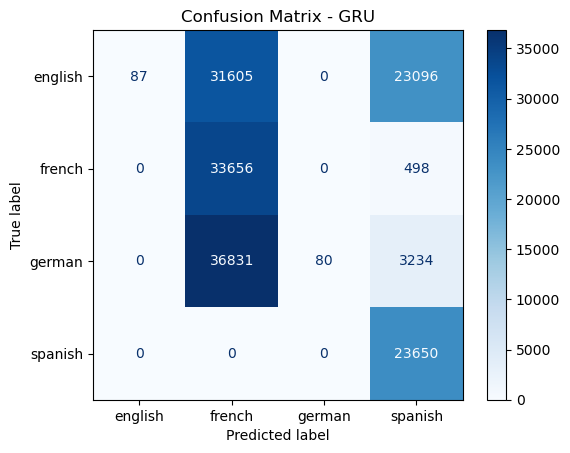

In [38]:
print("GRU Modeli Konfüzyon Matrisi:")
plot_confusion_matrix(model_gru, X_test_vectorized, y_test, label_encoder, "GRU")

BiLSTM Modeli Konfüzyon Matrisi:
4774/4774 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step


<Figure size 1000x800 with 0 Axes>

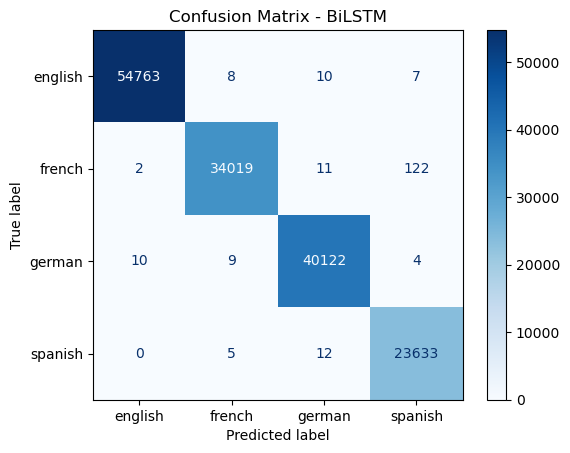

In [55]:
print("BiLSTM Modeli Konfüzyon Matrisi:")
plot_confusion_matrix(model_lstm, X_test_vectorized, y_test, label_encoder, "BiLSTM")


In [44]:
# Modeli değerlendir
def evaluate_model(model, X_test_vectorized, y_test):
    loss, accuracy = model.evaluate(X_test_vectorized, y_test)
    return accuracy, loss

print("BiLSTM Modeli Değerlendiriliyor...")
evaluate_model(model_bilstm, X_test_vectorized, y_test)

print("GRU Modeli Değerlendiriliyor...")
evaluate_model(model_gru, X_test_vectorized, y_test)

print("LSTM Modeli Değerlendiriliyor...")
evaluate_model(model_lstm, X_test_vectorized, y_test)

BiLSTM Modeli Değerlendiriliyor...
4774/4774 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9986 - loss: 0.0109
GRU Modeli Değerlendiriliyor...
4774/4774 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.3766 - loss: 1.3517
LSTM Modeli Değerlendiriliyor...
4774/4774 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9986 - loss: 0.0041


(0.9986905455589294, 0.0038664028979837894)

In [ ]:
# Kullanıcı girdisi için dil tahmini
def predict_language(model, vectorize_layer, label_encoder, input_text):
    input_text_vectorized = vectorize_layer([input_text]).numpy()
    prediction = model.predict(input_text_vectorized)
    predicted_class = prediction.argmax(axis=1)[0]
    predicted_language = label_encoder.inverse_transform([predicted_class])[0]
    return predicted_language

while True:
    input_text = input("Bir cümle girin (çıkmak için 'exit' yazın): ")
    if input_text.lower() == 'exit':
        print("Programdan çıkılıyor.")
        break
    language = predict_language(model_bilstm, vectorize_layer, label_encoder, input_text)
    print(f"Tahmin Edilen Dil: {language}")


Bir cümle girin (çıkmak için 'exit' yazın):  selam


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Tahmin Edilen Dil: french
